#**Sales Data Analysis Project**
Analyzing supermarket sales data using Python to identify trends, customer behavior, and business insights.

## 1. Data Loading

### 1.1 Import Libraries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from google.colab import files

### 1.2 Load Dataset

In [2]:
path = kagglehub.dataset_download("chadwambles/supermarket-sales")
print("Path to dataset files:", path)

100%|██████████| 36.5k/36.5k [00:00<00:00, 49.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/chadwambles/supermarket-sales/versions/4


In [3]:
df_path = os.path.join(path, 'sales.csv')
df = pd.read_csv(df_path)
df.head()

,sale_id,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points
0,1,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1
1,2,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0
2,3,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1
3,4,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0
4,5,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2


## 2. Data Exploration
Understanding the structure of the dataset.

### 2.1 Dataset Overview

In [4]:
print(df.info())
print(df.describe())
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sale_id           1000 non-null   int64  
 1   branch            1000 non-null   object 
 2   city              1000 non-null   object 
 3   customer_type     1000 non-null   object 
 4   gender            1000 non-null   object 
 5   product_name      1000 non-null   object 
 6   product_category  1000 non-null   object 
 7   unit_price        1000 non-null   float64
 8   quantity          1000 non-null   int64  
 9   tax               1000 non-null   float64
 10  total_price       1000 non-null   float64
 11  reward_points     1000 non-null   int64  
dtypes: float64(3), int64(3), object(6)
memory usage: 93.9+ KB
None
           sale_id   unit_price     quantity          tax  total_price  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean    500.500000  

## 3. Data Cleaning
Checking for missing values and duplicates.

### 3.1 Checking Missing Values & Duplicate Rows

In [5]:
print(df.isnull().sum())
print(df.duplicated().sum())

sale_id             0
branch              0
city                0
customer_type       0
gender              0
product_name        0
product_category    0
unit_price          0
quantity            0
tax                 0
total_price         0
reward_points       0
dtype: int64
0


## 4. Exploratory Data Analysis (EDA)
Analyzing trends and buisness questions.

### 4.1 Which product category sold the most?

In [6]:
df.groupby('product_category')['total_price'].sum()

,total_price
product_category,
Beverages,22983.32
Fruits,26197.45
Household,21615.84
Personal Care,27050.18
Stationery,20737.11


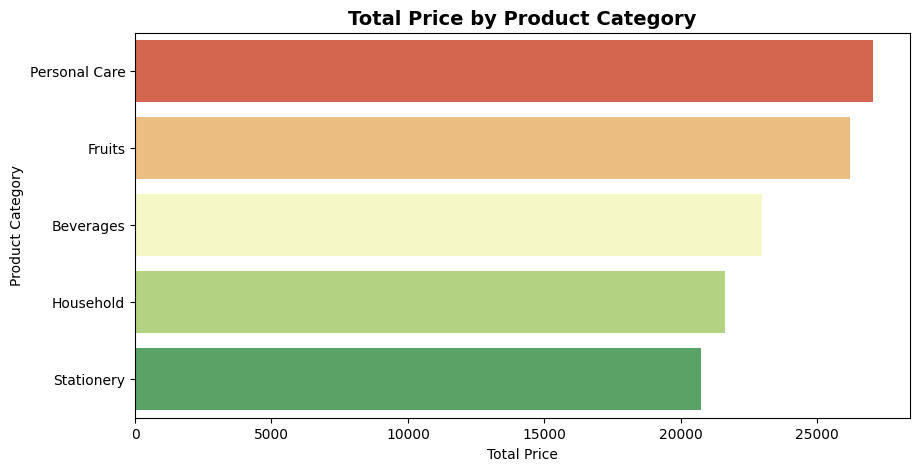

In [7]:
quantity_by_category = df.groupby('product_category')['total_price'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=quantity_by_category.values, y=quantity_by_category.index, hue=quantity_by_category.index, palette='RdYlGn')
plt.title('Total Price by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Price')
plt.ylabel('Product Category')
plt.show()

### 4.2 Which branch achieved the highest sales?

In [8]:
df.groupby('branch')['total_price'].sum()

,total_price
branch,
A,82811.64
B,35772.26


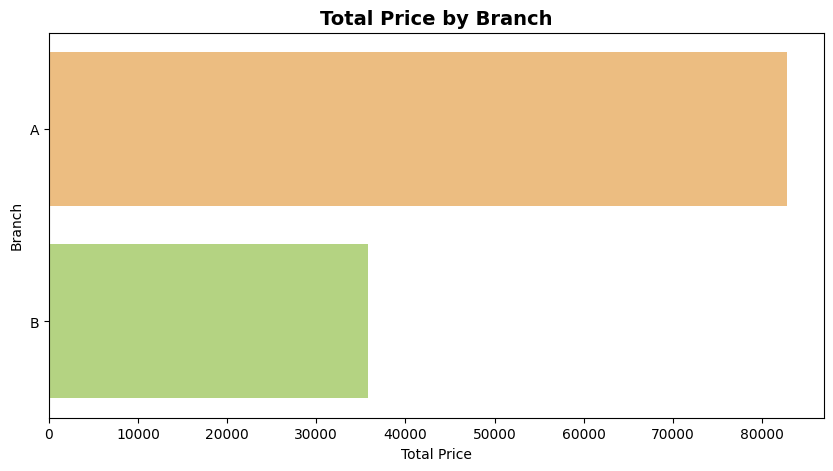

In [9]:
price_by_branch = df.groupby('branch')['total_price'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=price_by_branch.values, y=price_by_branch.index, hue=price_by_branch.index, palette='RdYlGn')
plt.title('Total Price by Branch', fontsize=14, fontweight='bold')
plt.xlabel('Total Price')
plt.ylabel('Branch')
plt.show()

### 4.3 Which city generated the highest revenue?



In [10]:
df.groupby('city')['total_price'].sum()

,total_price
city,
Chicago,42584.71
Los Angeles,35772.26
New York,40226.93


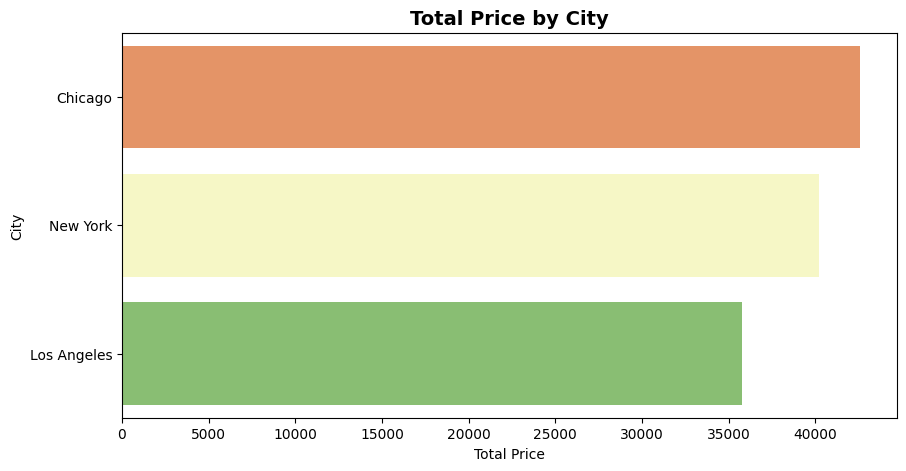

In [11]:
price_by_city = df.groupby('city')['total_price'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=price_by_city.values, y=price_by_city.index, hue=price_by_city.index, palette='RdYlGn')
plt.title('Total Price by City', fontsize=14, fontweight='bold')
plt.xlabel('Total Price')
plt.ylabel('City')
plt.show()

### 4.4 Is there a difference is spending based on gender?

In [12]:
df.groupby('gender')['total_price'].mean()

,total_price
gender,
Female,114.969174
Male,121.815246


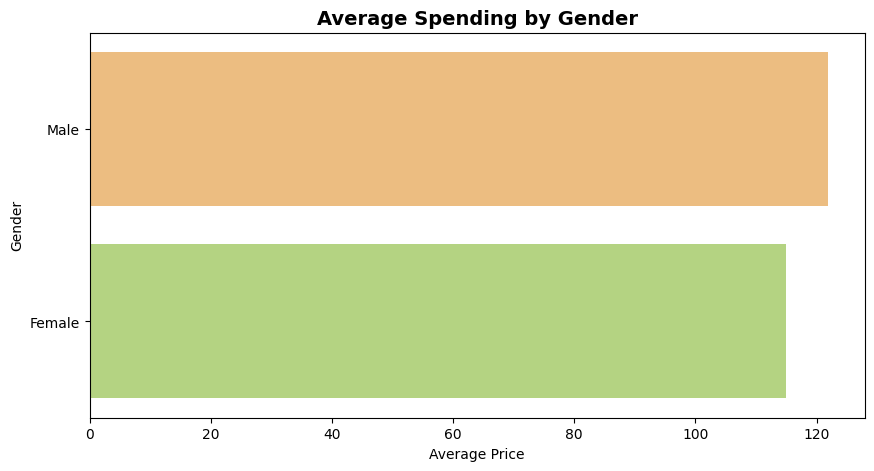

In [13]:
price_by_gender = df.groupby('gender')['total_price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=price_by_gender.values, y=price_by_gender.index, hue=price_by_gender.index, palette='RdYlGn')
plt.title('Average Spending by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Average Price')
plt.ylabel('Gender')
plt.show()

### 4.5 Do members spend more than normal customers?

In [14]:
df.groupby('customer_type')['total_price'].mean()

,total_price
customer_type,
Member,122.507035
Normal,114.401384


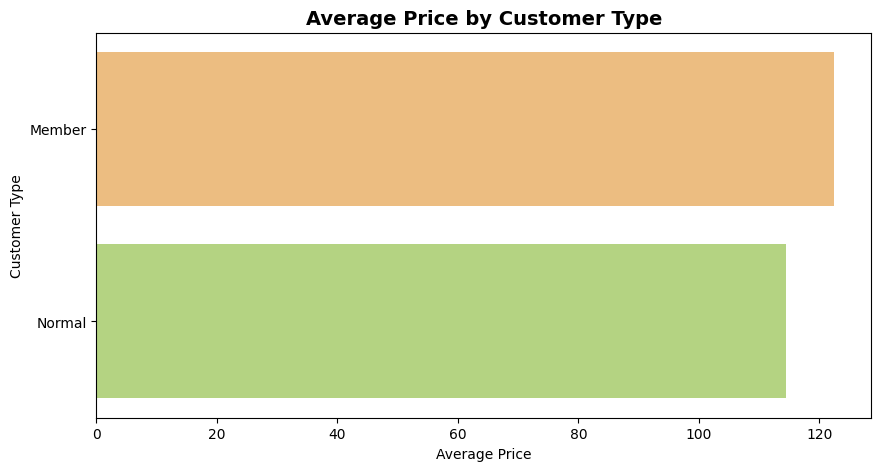

In [15]:
price_by_type = df.groupby('customer_type')['total_price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=price_by_type.values, y=price_by_type.index,hue=price_by_type.index, palette='RdYlGn')
plt.title('Average Price by Customer Type', fontsize=14, fontweight='bold')
plt.xlabel('Average Price')
plt.ylabel('Customer Type')
plt.show()

### 4.6 Which product generates the most reward points?

In [16]:
df.groupby('product_category')['reward_points'].sum()

,reward_points
product_category,
Beverages,1128
Fruits,1352
Household,1106
Personal Care,1483
Stationery,988


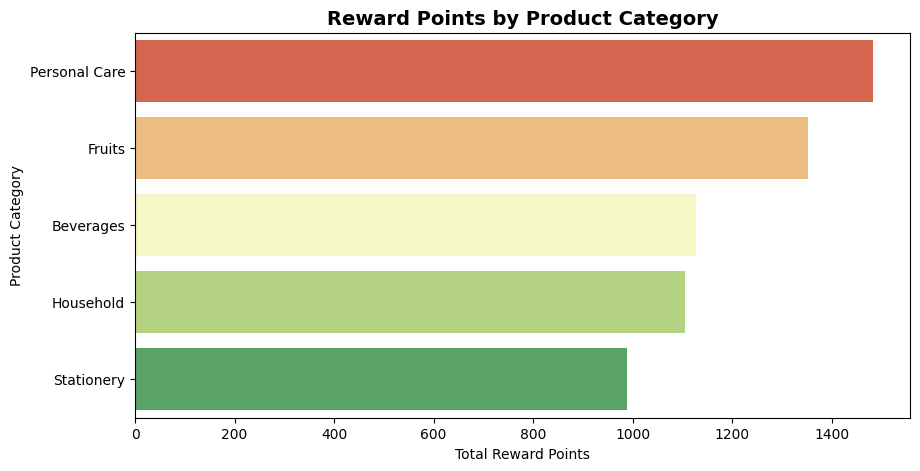

In [17]:
points_by_product = df.groupby('product_category')['reward_points'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=points_by_product.values, y=points_by_product.index, hue=points_by_product.index, palette='RdYlGn')
plt.title('Reward Points by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Reward Points')
plt.ylabel('Product Category')
plt.show()

### 4.7 What is the average tax paid per branch?

In [18]:
df.groupby('branch')['tax'].mean()

,tax
branch,
A,8.038234
B,7.178650


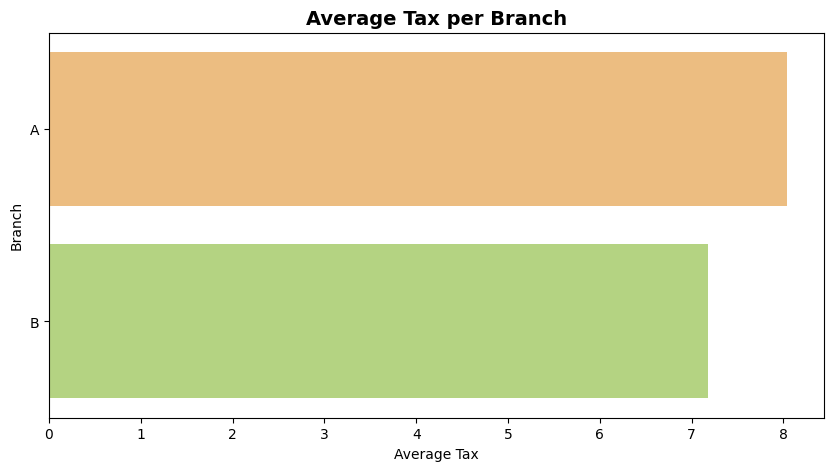

In [19]:
avg_tax_branch = df.groupby('branch')['tax'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=avg_tax_branch.values, y=avg_tax_branch.index, hue=avg_tax_branch.index, palette='RdYlGn')
plt.title('Average Tax per Branch', fontsize=14, fontweight='bold')
plt.xlabel('Average Tax')
plt.ylabel('Branch')
plt.show()

### 4.8 Top 5 Best-Selling Products (by quantity)

In [20]:
df.groupby('product_name')['quantity'].sum()

,quantity
product_name,
Apple,1741
Detergent,2010
Notebook,2165
Orange Juice,2183
Shampoo,2238


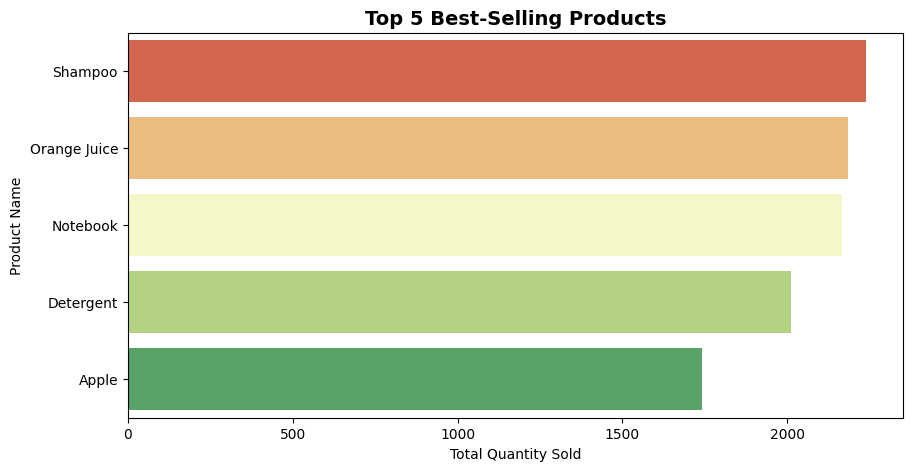

In [21]:
top_products = df.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette='RdYlGn')
plt.title('Top 5 Best-Selling Products', fontsize=14, fontweight='bold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Name')
plt.show()

## 5. Key Insights

- Personal Care was the top-selling category, generating 27,050 in total revenue.
- Branch A achieved the highest sales with a total of 82811.64, while Branch B had the lowest.
- Chicago generated the highest revenue among all cities, totaling 42584.71 .
- Male customers tend to spend more, with an average of 121.82
   compared to 114.97 for female customers.
- Member customers outspent Normal customers on average,
with 122.51 vs 114.40 per transaction.
- Personal Care category generated the most reward points with 1483 points, making it the most rewarding category.
- Branch A has the highest average tax per transaction at 8, indicating that customers there tend to spend more per purchase.
- Shampoo was the best-selling product with 2238 units sold.


## 6. Conclusion

This project analyzed supermarket sales data using Python and identified trends in product performance, branch sales, and customer purchasing behavior. Data visualization was used to present insights and better understand patterns within the dataset.